<a href="https://colab.research.google.com/github/kpate18/ECGR-4105/blob/main/homework2/Problem_3a.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

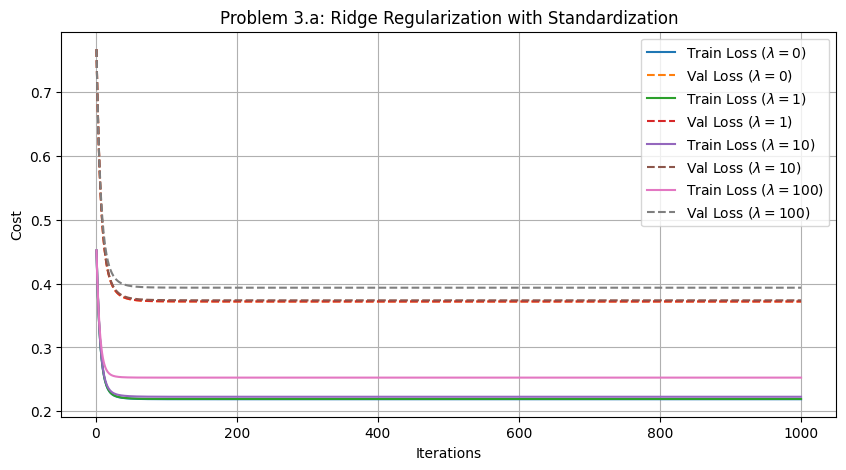

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler


np.random.seed(42)


df = pd.read_csv('Housing.csv')


features_3a = ['area', 'bedrooms', 'bathrooms', 'stories', 'parking']
X = df[features_3a].values
y = df['price'].values.reshape(-1, 1)


X_train_raw, X_val_raw, y_train_raw, y_val_raw = train_test_split(X, y, test_size=0.20, random_state=42)


scaler_X = StandardScaler()
X_train_std = np.c_[np.ones((X_train_raw.shape[0], 1)), scaler_X.fit_transform(X_train_raw)]
X_val_std = np.c_[np.ones((X_val_raw.shape[0], 1)), scaler_X.transform(X_val_raw)]


scaler_y = StandardScaler()
y_train_std = scaler_y.fit_transform(y_train_raw)
y_val_std = scaler_y.transform(y_val_raw)


def compute_train_cost(X, y, theta, lam):
   """Training loss includes L2 regularization penalty."""
   m = len(y)
   predictions = X.dot(theta)
   mse = (1 / (2 * m)) * np.sum(np.square(predictions - y))
   l2_penalty = (lam / (2 * m)) * np.sum(np.square(theta[1:]))
   return mse + l2_penalty


def compute_eval_cost(X, y, theta):
   """Validation/Evaluation loss excludes parameter penalty."""
   m = len(y)
   predictions = X.dot(theta)
   return (1 / (2 * m)) * np.sum(np.square(predictions - y))


def gradient_descent_l2(X_train, y_train, X_val, y_val, theta, alpha, iterations, lam):
   m_train = len(y_train)
   train_loss_history = np.zeros(iterations)
   val_loss_history = np.zeros(iterations)

   for i in range(iterations):
       predictions = X_train.dot(theta)
       errors = predictions - y_train

       grad_penalty = (lam / m_train) * theta
       grad_penalty[0] = 0

       gradients = (1 / m_train) * X_train.T.dot(errors) + grad_penalty
       theta = theta - alpha * gradients

       train_loss_history[i] = compute_train_cost(X_train, y_train, theta, lam)
       val_loss_history[i] = compute_eval_cost(X_val, y_val, theta)

   return theta, train_loss_history, val_loss_history


alpha = 0.05
iterations = 1000
lambdas = [0, 1, 10, 100]


plt.figure(figsize=(10, 5))


for lam in lambdas:
   theta_init = np.zeros((X_train_std.shape[1], 1))
   theta_opt, train_loss, val_loss = gradient_descent_l2(
       X_train_std, y_train_std, X_val_std, y_val_std, theta_init, alpha, iterations, lam
   )
   plt.plot(range(1, iterations + 1), train_loss, label=rf'Train Loss ($\lambda={lam}$)')
   plt.plot(range(1, iterations + 1), val_loss, label=rf'Val Loss ($\lambda={lam}$)', linestyle='--')


plt.xlabel('Iterations')
plt.ylabel('Cost')
plt.title('Problem 3.a: Ridge Regularization with Standardization')
plt.legend()
plt.grid(True)
plt.show()
